Content:

(1) : Short term memory

(2) : Long term memory

(3) : Streaming (.stream() and .astream())

(4) : Human in the loop

In [1]:
from dotenv import load_dotenv
from typing import Annotated, List
from langgraph.graph import StateGraph
import os
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from langchain_core.messages import AnyMessage,HumanMessage
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode,tools_condition

In [2]:
#Tools

import arxiv
import wikipedia
from duckduckgo_search import DDGS
from langchain.tools import tool

@tool
def search_arxiv(query_string: str, max_results: int = 2) -> list[dict]:
    """
    Queries the official arXiv API for research papers.
    Returns a list of dictionaries with paper metadata.
    """
    try:
        client = arxiv.Client()
        search = arxiv.Search(
            query=query_string,
            max_results=max_results,
            sort_by=arxiv.SortCriterion.Relevance
        )
        
        papers = []
        # Calling client.results() is the modern, stable 2.x+ pattern
        for result in client.results(search):
            papers.append({
                "title": result.title,
                "summary": result.summary,
                "url": result.entry_id,
                "published": result.published.strftime("%Y-%m-%d"),
                "authors": [author.name for author in result.authors]
            })
        return papers
    except Exception as e:
        return [{"error": f"arXiv search failed: {str(e)}"}]
@tool
def search_wikipedia(query_string: str, sentences: int = 3) -> str:
    """
    Queries Wikipedia for summary definitions.
    Handles disambiguation conflicts safely.
    """
    # Force Wikipedia to look up variations cleanly
    wikipedia.set_lang("en") 
    try:
        # Bypassing background parsing frameworks saves memory
        return wikipedia.summary(query_string, sentences=sentences, auto_suggest=False)
    except Exception as e:
        return f"Wikipedia error: {str(e)}"
@tool
def weather_api(query: str = "") -> str:
    """
    It gives us the weather information of the place.
    """
    return "weather api called: It is currently clear and 24°C in Pune."

@tool
def human_approval():
    '''
    The tool should only be called if there is need for human intervention.
    '''
    pass
@tool
def math_operation(a:int,b:int,operator:str):
    '''
    pick this tool when user want to perform some mathematical operations only when there are two numbers.
    operators may be add, sub, mul, divide

    '''
    op=None
    if operator =="add":
        return a+b
    elif operator=="sub":
        return abs(a-b)
    elif operator=="mul":
        return a*b
    elif operator=="div":
        return a/b
    else :
        return None


In [3]:
load_dotenv()
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")
tools = [
    search_arxiv,search_wikipedia,weather_api,human_approval,math_operation
]

# Creating Short Term Memory and Long Term Memory of the agent

# Short Term Memory

!) Short term memory: We will use Memorysaver

2)Lifespan: till the programs run

3)Not good for production and long term memory.

In [4]:
'''
BUT LETS SEE, IF WITHOUT MEMORY , HOW IT BEHAVES WITHOUT MEMORY.
'''
#creating state 
class State(BaseModel):
    messages: Annotated[List[AnyMessage],add_messages]=Field(default_factory=list)

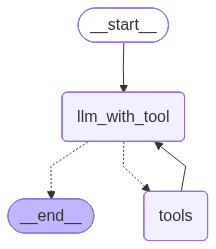

In [5]:
llm=ChatOpenAI(
    model="gpt-4o-mini"
).bind_tools(tools=tools)


#CREATING NODE
def llm_with_tool(state:State):
    
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode(tools=tools))

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
# builder.add_edge("llm_with_tool",END)

graph=builder.compile()

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
#LETS TEST OUR GRAPH
res=graph.invoke({"messages":"Hi, I am saurav"})
res['messages']

[HumanMessage(content='Hi, I am saurav', additional_kwargs={}, response_metadata={}, id='e2a1415a-2271-4c76-bd49-faa4d7864921'),
 AIMessage(content='Hello Saurav! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 221, 'total_tokens': 234, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019edc96-c01a-7403-9d4a-d9e52a1ec0bd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 221, 'output_tokens': 13, 'total_tokens': 234, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [7]:
# see, Its not remembering my name, since it doesn't have memory.
res=graph.invoke({"messages":["user","what is my name?"]})
res['messages']

[HumanMessage(content='user', additional_kwargs={}, response_metadata={}, id='7b75b7d0-8a97-4fe1-abe4-e016c871a244'),
 HumanMessage(content='what is my name?', additional_kwargs={}, response_metadata={}, id='e3b4e40c-ec92-4ca9-980e-93c135b26d5c'),
 AIMessage(content="I'm sorry, but I don't have access to your name or personal information. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 225, 'total_tokens': 248, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019edc96-c529-7af0-bddc-1f256db8dca2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 225, 'output_tokens': 23, 'total_toke

USING MEMORYSAVER:  short term memory

In [8]:
# Using Memorysaver
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

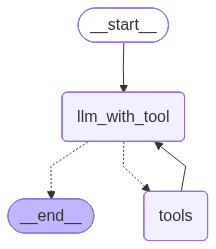

In [9]:
#Lets define our states, edges again .
llm=ChatOpenAI(
    model="gpt-4o-mini"
).bind_tools(tools=tools)


#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode(tools=tools))

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
# builder.add_edge("llm_with_tool",END)

graph=builder.compile(checkpointer=memory)
config = {"configurable": {"thread_id": "chat123"}}

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [10]:
events = graph.invoke(
    {"messages": [("user", "My name is saurav, and I live in Pune")]}, 
    config
)
print(events['messages'][-1].content)

Hello Saurav! How can I assist you today?


In [11]:
#  Now the memory is working for agent.
events = graph.invoke(
    {"messages": [HumanMessage(content="hey, whats my name")]}, 
    config
)
print(events['messages'][-1].content)

Your name is Saurav.


In [12]:
'''
Note: There are three ways by which we can write in invoke 
[("user", "text")]
[HumanMessage(content="hey, whats my name")]
["text"]
All of the above are converted anyhow in [HumanMessage(content="hey, whats my name")] , so its the best production practice.

'''

'\nNote: There are three ways by which we can write in invoke \n[("user", "text")]\n[HumanMessage(content="hey, whats my name")]\n["text"]\nAll of the above are converted anyhow in [HumanMessage(content="hey, whats my name")] , so its the best production practice.\n\n'

In [13]:
'''Problem with Short term memory'''
# It will be destroyed upon the finish of the program.
# NOT GOOD FOR PRODUCTION

'Problem with Short term memory'

## Long Term Memory

In [14]:
!pip install --upgrade langgraph langgraph-checkpoint langgraph-checkpoint-sqlite -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [15]:
# conn.close()

In [16]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
conn = sqlite3.connect("/workspaces/LangGraph-practice/BuildingAgent/agent-db/memory.db", check_same_thread=False)
long_term_memory = SqliteSaver(conn)


In [17]:
#conn.close() # uncomment when we are about to remove the .db

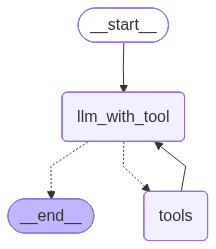

In [18]:
#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode(tools=tools))

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
# builder.add_edge("llm_with_tool",END)

graph=builder.compile(checkpointer=long_term_memory)
config = {"configurable": {"thread_id": "chat_001"}}

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
config = {"configurable": {"thread_id": "longtermchat#123"}}
res = graph.invoke(
    {"messages": [HumanMessage(content="I am saurav sagar, Hi")]}, 
    config=config # <--- Pass the config dictionary variable here
)
print(res['messages'][-1].content)


Hello, Saurav Sagar! How can I assist you today?


In [20]:
res = graph.invoke(
    {"messages": [HumanMessage(content="whats my name")]}, 
    config=config # <--- Pass the config dictionary variable here
)
print(res['messages'][-1].content)

Your name is Saurav Sagar.


In [21]:
res = graph.invoke(
    {"messages": [HumanMessage(content="have I told you about my name")]}, 
    config=config # <--- Pass the config dictionary variable here
)
print(res['messages'][-1].content)

Yes, you have mentioned that your name is Saurav Sagar.


## Streaming in Langgraph

In [22]:
'''
Two types of streaming technique
1) .stream() (Sync) :It blocks your application's execution thread while waiting for data chunks.
2) .astream() (Async) : Essential for web applications (like FastAPI). It allows your server to handle thousands of users concurrently without blocking the main event loop.

Both of them support the below streaming modes
stream_mode -> values / updates / messages

we will see all of them one by one

'''

"\nTwo types of streaming technique\n1) .stream() (Sync) :It blocks your application's execution thread while waiting for data chunks.\n2) .astream() (Async) : Essential for web applications (like FastAPI). It allows your server to handle thousands of users concurrently without blocking the main event loop.\n\nBoth of them support the below streaming modes\nstream_mode -> values / updates / messages\n\nwe will see all of them one by one\n\n"

In [23]:
conn = sqlite3.connect("/workspaces/LangGraph-practice/BuildingAgent/agent-db/streaming.db", check_same_thread=False)
streaming_memory = SqliteSaver(conn)

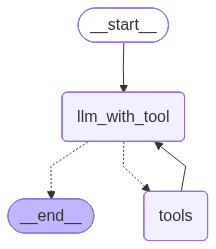

In [24]:
# Lets take the older graph only
#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode(tools=tools))

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
# builder.add_edge("llm_with_tool",END)

graph=builder.compile(checkpointer=streaming_memory)
config = {"configurable": {"thread_id": "stream_005"}}

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [25]:
import pprint
stream_res=graph.stream(
    {"messages":[HumanMessage(content="hey ruby whats up??")]},
    # stream_mode="values", # It gives us the whole track of messages and updates.
    # stream_mode="updates", # It gives us the delta changed or appended mesg only
    stream_mode="messages", # IT gives the real chatgpt effect
    config=config
)

In [26]:
# for msg in stream_res:
#     pprint.pprint(msg['llm_with_tool']['messages'][0].content)
import time

#for getting stereaming message effect 
for msg, metadata in stream_res:
    # 1. We only want to stream chunks coming from your LLM node
    if metadata.get("langgraph_node") == "llm_with_tool":
        # 2. Print content chunk-by-chunk without adding stray newlines
        if msg.content:
            print(msg.content, end="", flush=True)
            time.sleep(0.010)

Hello! I'm here and ready to assist you. What would you like to know or discuss today?

## HUMAN In the Loop

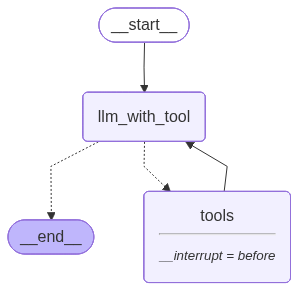

In [27]:
# Lets take the older graph only
#CREATING NODE
def llm_with_tool(state:State):
    return {"messages":[llm.invoke(state.messages)]}

#the other node is tool node which is alredy imported.

#BUILDING GRAPH AND ADDING NODE
builder=StateGraph(State)
builder.add_node("llm_with_tool",llm_with_tool)
builder.add_node("tools",ToolNode(tools=tools))

#CREATING EDGE FOR GRAPH
builder.add_edge(START,"llm_with_tool")
builder.add_conditional_edges(
    "llm_with_tool",
    tools_condition
)
builder.add_edge("tools","llm_with_tool")
# builder.add_edge("llm_with_tool",END)

graph=builder.compile(
    checkpointer=streaming_memory,
    interrupt_before=["tools"]   # ADDED THE HUMAN IN LOOP; tHE CODE WILL STOP HERE
    )
config = {"configurable": {"thread_id": "HIL_014"}}

#Graph visuilisation
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
initial_input = {"messages": [HumanMessage(content="What is the weather today in Pune?")]}

stream_res = graph.stream(
    initial_input,
    stream_mode="updates",
    config=config
)

for msg in stream_res:
    print(msg)

{'llm_with_tool': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4GTkzXNmM7WaIsfnKsya1RXf', 'function': {'arguments': '{"query":"Pune"}', 'name': 'weather_api'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 350, 'total_tokens': 365, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019edc96-fae9-7ed3-8509-00a6ebb252f9-0', tool_calls=[{'name': 'weather_api', 'args': {'query': 'Pune'}, 'id': 'call_4GTkzXNmM7WaIsfnKsya1RXf', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 350, 'output_tokens': 15, 'total_tokens': 365, 'input_token_details': {'audio': 0, 'cache_r

In [29]:
# Fetch the current graph state for this specific thread
current_state = graph.get_state(config)

print("Next node to execute:", current_state.next)
# Output will be: Next node to execute: ('tools',)

print("\nPending Tool Calls to approve:")
print(current_state.values["messages"][1].tool_calls)

Next node to execute: ('tools',)

Pending Tool Calls to approve:
[{'name': 'weather_api', 'args': {'query': 'Pune'}, 'id': 'call_2eh7H1xN1DH64PEyLAtGGcrX', 'type': 'tool_call'}]


In [30]:
# print("--- Resuming execution after human approval ---")

# Pass None to resume execution from the checkpointed save point
resume_res = graph.stream(
    None,
    stream_mode="updates",
    config=config
)

for update in resume_res:
    print(update)


{'tools': {'messages': [ToolMessage(content='weather api called: It is currently clear and 24°C in Pune.', name='weather_api', id='ec810324-9437-4be2-9109-9bf5ae202db0', tool_call_id='call_4GTkzXNmM7WaIsfnKsya1RXf')]}}
{'llm_with_tool': {'messages': [AIMessage(content='The weather today in Pune is clear with a temperature of 24°C.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 388, 'total_tokens': 404, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019edc96-ff48-7cc2-a39c-fba2fa9e1659-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 388, 'output_tokens': 16, 'total_tokens': 404, 'input_token_details': {'a

In [31]:
initial_input = {"messages": [HumanMessage(content="what is 10-14?")]}

stream_res = graph.stream(
    initial_input,
    stream_mode="updates",
    config=config
)

for msg in stream_res:
    print(msg)

#waiting for the approval.

{'llm_with_tool': {'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_6KcwLO5H3BhlX4oAkk01Z1yz', 'function': {'arguments': '{"a":10,"b":14,"operator":"sub"}', 'name': 'math_operation'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 418, 'total_tokens': 440, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019edc97-02ed-75a2-aca6-47ca7ad29b81-0', tool_calls=[{'name': 'math_operation', 'args': {'a': 10, 'b': 14, 'operator': 'sub'}, 'id': 'call_6KcwLO5H3BhlX4oAkk01Z1yz', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 418, 'output_tokens': 22, 'total_tokens': 440, 'i

In [32]:
resume_res = graph.stream(
    None,
    stream_mode="updates",
    config=config
)

for update in resume_res:
    print(update)


{'tools': {'messages': [ToolMessage(content='4', name='math_operation', id='e9a7584e-cf6e-41c3-9674-80388253d7f4', tool_call_id='call_6KcwLO5H3BhlX4oAkk01Z1yz')]}}


{'llm_with_tool': {'messages': [AIMessage(content='The result of 10 - 14 is -4.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 449, 'total_tokens': 462, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019edc97-0751-71a1-8617-3f663d4fcaf9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 449, 'output_tokens': 13, 'total_tokens': 462, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
